<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/ELM/Prediction_of_O3_based_ELM_ver2.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !Install hpelm if not already installed
# !pip install hpelm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from hpelm import ELM

# -------------------------------------------------
# Load dataset
# -------------------------------------------------
data = pd.read_csv("air_quality_o3.csv")

features = ["AMP_TMP","CO","NO","NO2","Nox","RH","SO2","WD","WS","PM10"]
target = "O3"

X = data[features].values
y = data[target].values

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=28
)

# Validation split from training set (20% of training)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=28
)

# -------------------------------------------------
# VAF function
# -------------------------------------------------
def vaf(y_true, y_pred):
    return 1 - np.var(y_true - y_pred) / np.var(y_true)

# =================================================
# 1. LINEAR REGRESSION
# =================================================
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions for all datasets
y_train_pred_lr = lr.predict(X_train)
y_val_pred_lr   = lr.predict(X_val)
y_test_pred_lr  = lr.predict(X_test)

# =================================================
# 2. IMPROVED ELM (VALIDATION-BASED GRID SEARCH)
# =================================================
neurons_list = [20, 30, 50]       # fewer neurons
alpha_list = [1, 5, 10, 50]      # stronger regularization

best_model = None
best_config = None
best_vaf = -np.inf

for n_hidden in neurons_list:
    for alpha in alpha_list:
        elm = ELM(X_tr.shape[1], 1)
        elm.add_neurons(n_hidden, "sigm")  # smoother than tanh
        elm.train(X_tr, y_tr.reshape(-1,1), "Ridge", alpha=alpha)

        y_val_pred_tmp = elm.predict(X_val).flatten()
        vaf_val = vaf(y_val, y_val_pred_tmp)

        if vaf_val > best_vaf:
            best_vaf = vaf_val
            best_model = elm
            best_config = (n_hidden, alpha)

print(f"\nBest ELM configuration:")
print(f"Hidden Neurons = {best_config[0]}, Alpha = {best_config[1]}")
print(f"Validation VAF = {best_vaf:.4f}")

# Final ELM predictions for all datasets
y_train_pred_elm = best_model.predict(X_train).flatten()
y_val_pred_elm   = best_model.predict(X_val).flatten()
y_test_pred_elm  = best_model.predict(X_test).flatten()

# =================================================
# 3. PERFORMANCE METRICS FUNCTION
# =================================================
def metrics(y_true, y_pred):
    return (
        mean_squared_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        vaf(y_true, y_pred),
        r2_score(y_true, y_pred)
    )

# LR metrics
mse_tr_lr, rmse_tr_lr, vaf_tr_lr, r2_tr_lr = metrics(y_train, y_train_pred_lr)
mse_val_lr, rmse_val_lr, vaf_val_lr, r2_val_lr = metrics(y_val, y_val_pred_lr)
mse_te_lr, rmse_te_lr, vaf_te_lr, r2_te_lr = metrics(y_test, y_test_pred_lr)

# ELM metrics
mse_tr_elm, rmse_tr_elm, vaf_tr_elm, r2_tr_elm = metrics(y_train, y_train_pred_elm)
mse_val_elm, rmse_val_elm, vaf_val_elm, r2_val_elm = metrics(y_val, y_val_pred_elm)
mse_te_elm, rmse_te_elm, vaf_te_elm, r2_te_elm = metrics(y_test, y_test_pred_elm)

# =================================================
# 4. PERFORMANCE TABLE
# =================================================
performance_df = pd.DataFrame({
    "Model": [
        "Linear Regression", "Linear Regression", "Linear Regression",
        "ELM", "ELM", "ELM"
    ],
    "Dataset": [
        "Train", "Validation", "Test",
        "Train", "Validation", "Test"
    ],
    "MSE": [
        mse_tr_lr, mse_val_lr, mse_te_lr,
        mse_tr_elm, mse_val_elm, mse_te_elm
    ],
    "RMSE": [
        rmse_tr_lr, rmse_val_lr, rmse_te_lr,
        rmse_tr_elm, rmse_val_elm, rmse_te_elm
    ],
    "VAF": [
        vaf_tr_lr, vaf_val_lr, vaf_te_lr,
        vaf_tr_elm, vaf_val_elm, vaf_te_elm
    ],
    "R2": [
        r2_tr_lr, r2_val_lr, r2_te_lr,
        r2_tr_elm, r2_val_elm, r2_te_elm
    ]
})

print("\n=================== PERFORMANCE TABLE ===================\n")
performance_df


Best ELM configuration:
Hidden Neurons = 50, Alpha = 10
Validation VAF = 0.7610

=================== PERFORMANCE TABLE ===================



,Model,Dataset,MSE,RMSE,VAF,R2
0,Linear Regression,Train,43.395379,6.587517,0.611330,0.611330
1,Linear Regression,Validation,40.215439,6.341564,0.646795,0.639179
2,Linear Regression,Test,33.065577,5.750268,0.665033,0.662404
3,ELM,Train,30.852285,5.554483,0.723810,0.723672
4,ELM,Validation,26.879137,5.184509,0.760984,0.758835
5,ELM,Test,32.857636,5.732158,0.672683,0.664527


In [ ]:
# Features list
features = ["AMP_TMP","CO","NO","NO2","Nox","RH","SO2","WD","WS","PM10"]

# Print Linear Regression equation
print("\n================ LINEAR REGRESSION MODEL EQUATION ================\n")
equation = f"O3 = {lr.intercept_:.4f}"

for coef, feature in zip(lr.coef_, features):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} {abs(coef):.4f}*{feature}"

print(equation)



================ LINEAR REGRESSION MODEL EQUATION ================

O3 = 26.1963 - 3.6460*AMP_TMP - 0.0980*CO - 1.9464*NO + 8.5817*NO2 - 9.9492*Nox + 0.2261*RH + 0.1874*SO2 - 2.0801*WD + 0.4994*WS + 1.8616*PM10


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from hpelm import ELM
import matplotlib.pyplot as plt

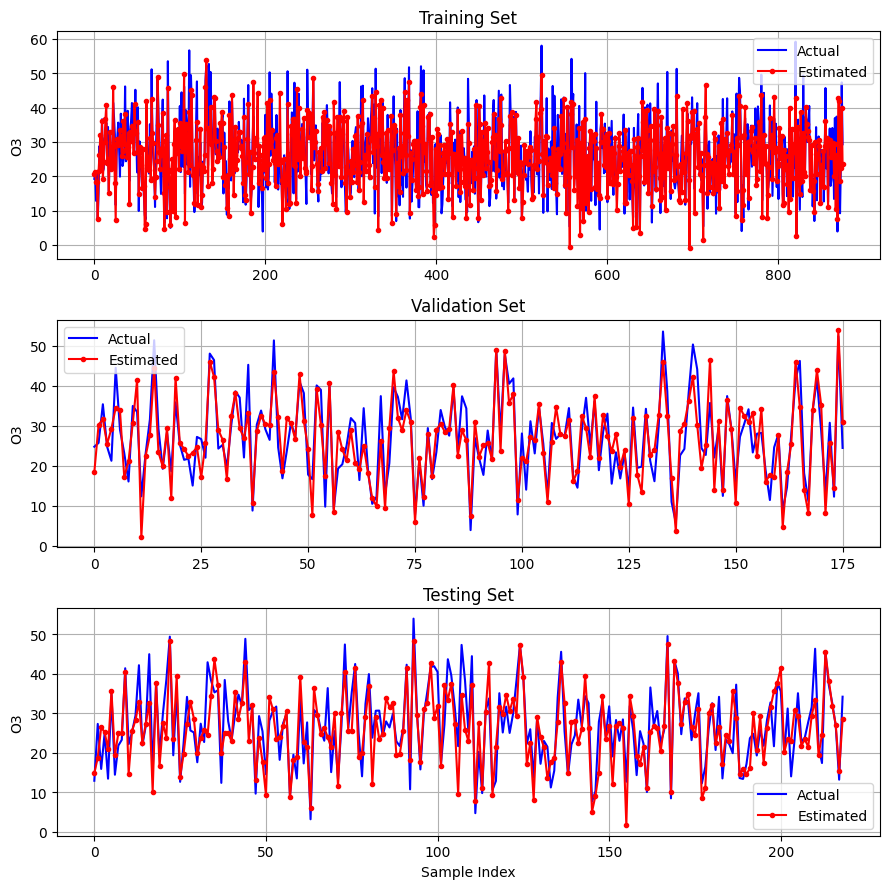

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(9,9), tight_layout=True)

# Training
axs[0].plot(y_train, '-b', label='Actual')
axs[0].plot(y_train_pred_elm, '.-r', label='Estimated')
axs[0].set_title('Training Set')
axs[0].set_ylabel('O3')
axs[0].legend()
axs[0].grid(True)

# Validation
axs[1].plot(y_val, '-b', label='Actual')
axs[1].plot(y_val_pred_elm, '.-r', label='Estimated')
axs[1].set_title('Validation Set')
axs[1].set_ylabel('O3')
axs[1].legend()
axs[1].grid(True)

# Testing
axs[2].plot(y_test, '-b', label='Actual')
axs[2].plot(y_test_pred_elm, '.-r', label='Estimated')
axs[2].set_title('Testing Set')
axs[2].set_xlabel('Sample Index')
axs[2].set_ylabel('O3')
axs[2].legend()
axs[2].grid(True)

plt.savefig("ELM_All_Sets_Response.png", dpi=300)
plt.show()


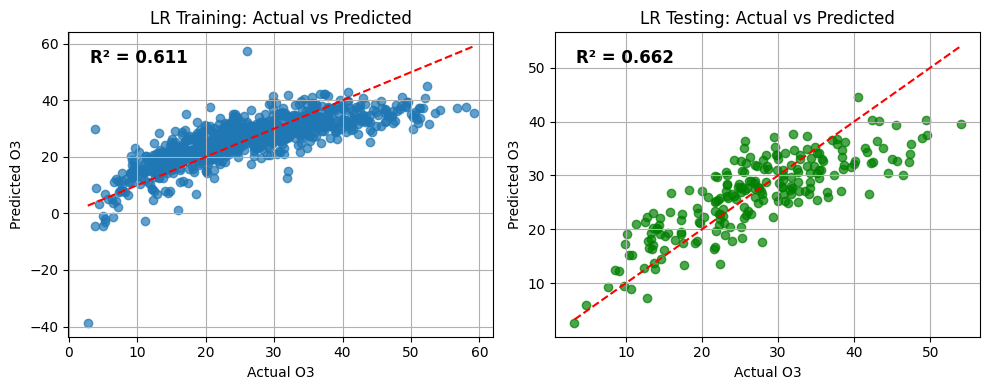

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# === R2 for Linear Regression ===
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

# === FIGURE 1: Linear Regression ===
fig, axs = plt.subplots(1, 2, figsize=(10,4), tight_layout=True)

# --- Training ---
axs[0].scatter(y_train, y_train_pred_lr, alpha=0.7)
axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axs[0].set_title("LR Training: Actual vs Predicted")
axs[0].set_xlabel("Actual O3")
axs[0].set_ylabel("Predicted O3")
axs[0].text(0.05, 0.9, f"R² = {r2_train_lr:.3f}", transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')
axs[0].grid(True)

# --- Testing ---
axs[1].scatter(y_test, y_test_pred_lr, alpha=0.7, color='green')
axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[1].set_title("LR Testing: Actual vs Predicted")
axs[1].set_xlabel("Actual O3")
axs[1].set_ylabel("Predicted O3")
axs[1].text(0.05, 0.9, f"R² = {r2_test_lr:.3f}", transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')
axs[1].grid(True)

plt.savefig("LR_Correlation.png", dpi=300)
plt.show()

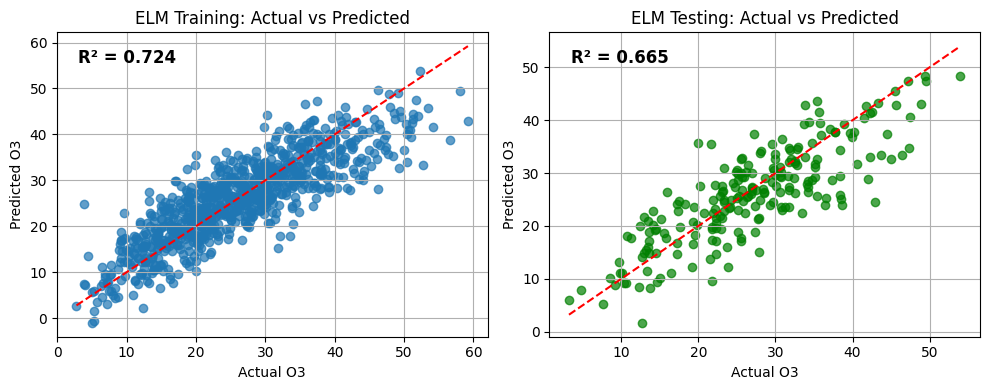

In [ ]:
# === R2 for ELM ===
r2_train_elm = r2_score(y_train, y_train_pred_elm)
r2_test_elm = r2_score(y_test, y_test_pred_elm)

# === FIGURE 2: ELM ===
fig, axs = plt.subplots(1, 2, figsize=(10,4), tight_layout=True)

# --- Training ---
axs[0].scatter(y_train, y_train_pred_elm, alpha=0.7)
axs[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axs[0].set_title("ELM Training: Actual vs Predicted")
axs[0].set_xlabel("Actual O3")
axs[0].set_ylabel("Predicted O3")
axs[0].text(0.05, 0.9, f"R² = {r2_train_elm:.3f}", transform=axs[0].transAxes,
            fontsize=12, fontweight='bold')
axs[0].grid(True)

# --- Testing ---
axs[1].scatter(y_test, y_test_pred_elm, alpha=0.7, color='green')
axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[1].set_title("ELM Testing: Actual vs Predicted")
axs[1].set_xlabel("Actual O3")
axs[1].set_ylabel("Predicted O3")
axs[1].text(0.05, 0.9, f"R² = {r2_test_elm:.3f}", transform=axs[1].transAxes,
            fontsize=12, fontweight='bold')
axs[1].grid(True)

plt.savefig("ELM_Correlation.png", dpi=300)
plt.show()


In [ ]:
data.describe()

,AMP_TMP,CO,NO,NO2,Nox,RH,SO2,WD,WS,PM10,O3
count,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000,1095.000000
mean,22.828889,0.387773,4.538562,11.245281,15.786744,80.052298,2.623121,190.417708,1.701910,37.979963,26.297766
std,5.265200,0.125974,2.678366,3.526464,5.244952,8.446745,1.583075,44.479594,0.675993,21.226532,10.448088
min,9.225000,0.037500,0.278750,0.824167,1.103333,46.290000,0.262500,52.460000,0.779583,3.833333,2.762500
25%,18.771458,0.300000,2.662708,8.713333,12.020417,74.204167,1.802083,159.243750,1.310000,25.311667,18.920417
50%,23.010417,0.370000,3.925833,10.897500,15.340000,80.305417,2.312500,185.715833,1.562500,34.833333,25.550000
75%,27.685000,0.466875,5.904167,13.685625,19.098333,86.270000,3.041667,220.422917,1.904167,46.479167,33.291667
max,32.250000,0.940000,29.379583,27.203333,43.938333,97.083333,22.750000,302.298333,8.609583,377.500000,59.208333
